In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv('../datasets/wine_data.csv')

In [38]:
df.shape

(177, 14)

<Axes: xlabel='15.6', ylabel='Count'>

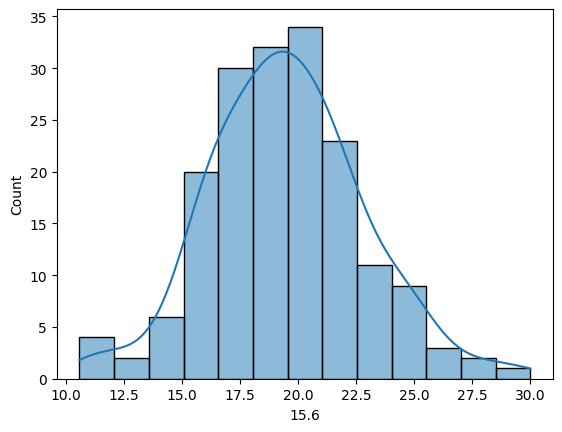

In [39]:
sns.histplot(df['15.6'],kde=True)

In [40]:
df['15.6'].describe()

count    177.000000
mean      19.516949
std        3.336071
min       10.600000
25%       17.200000
50%       19.500000
75%       21.500000
max       30.000000
Name: 15.6, dtype: float64

<Axes: xlabel='15.6'>

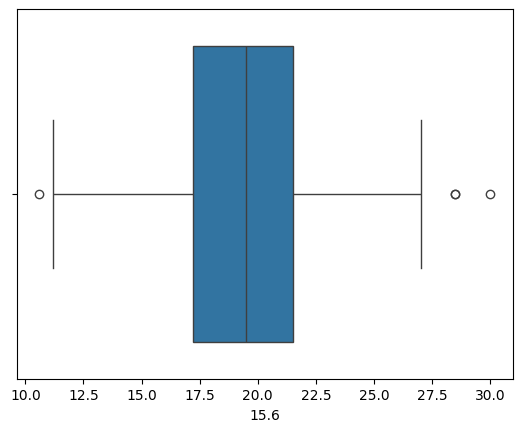

In [41]:
sns.boxplot(x=df['15.6'])

In [42]:
percentile25 = df['15.6'].quantile(0.25)
percentile75 = df['15.6'].quantile(0.75)

In [43]:
percentile25

np.float64(17.2)

In [44]:
percentile75

np.float64(21.5)

In [45]:
iqr = percentile75 - percentile25

In [46]:
iqr

np.float64(4.300000000000001)

In [47]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [48]:
upper_limit

np.float64(27.950000000000003)

In [49]:
lower_limit

np.float64(10.749999999999998)

In [50]:
df[df['15.6']>upper_limit]

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
72,2,12.99,1.67,2.60,30.0,139,3.30,2.89,0.21,1.96,3.35,1.31,3.50,985
120,2,11.56,2.05,3.23,28.5,119,3.18,5.08,0.47,1.87,6.00,0.93,3.69,465
126,2,11.79,2.13,2.78,28.5,92,2.13,2.24,0.58,1.76,3.00,0.97,2.44,466


In [51]:
df[df['15.6']<lower_limit]

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
58,2,12.37,0.94,1.36,10.6,88,1.98,0.57,0.28,0.42,1.95,1.05,1.82,520


# Trimming

In [52]:
new_df = df[(df['15.6']<upper_limit) & (df['15.6']>lower_limit)]

In [53]:
new_df

,1,14.23,1.71,2.43,15.6,127,2.8,3.06,.28,2.29,5.64,1.04,3.92,1065
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
173,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
174,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
175,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [77]:
df['15.6'].skew()

np.float64(0.20407561105896121)

In [78]:
new_df['15.6'].skew()

np.float64(-0.006223755348432815)

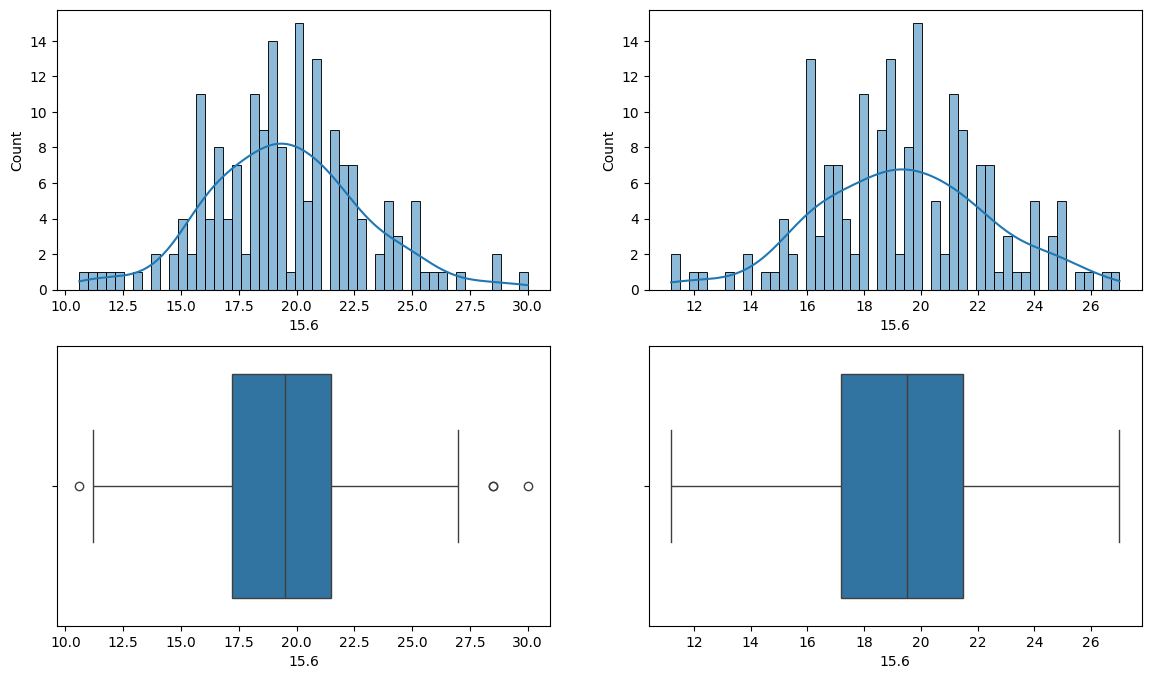

In [72]:
plt.figure(figsize=(14,8))
plt.subplot(221)
sns.histplot(df['15.6'],kde=True,bins=50)
plt.subplot(223)
sns.boxplot(x=df['15.6'])
plt.subplot(222)
sns.histplot(new_df['15.6'],kde=True,bins=50)
plt.subplot(224)
sns.boxplot(x=new_df['15.6'])
plt.show()

# Capping

In [ ]:
#np.where(condtion,if true replace with,if false replace with)

In [73]:
new_df_cap = df.copy()

In [74]:
new_df_cap['15.6'] = np.where(
    new_df_cap['15.6']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['15.6']<lower_limit,
        lower_limit,
        new_df_cap['15.6']
    )
)

In [76]:
new_df_cap['15.6'].describe()

count    177.000000
mean      19.500000
std        3.284026
min       10.750000
25%       17.200000
50%       19.500000
75%       21.500000
max       27.950000
Name: 15.6, dtype: float64

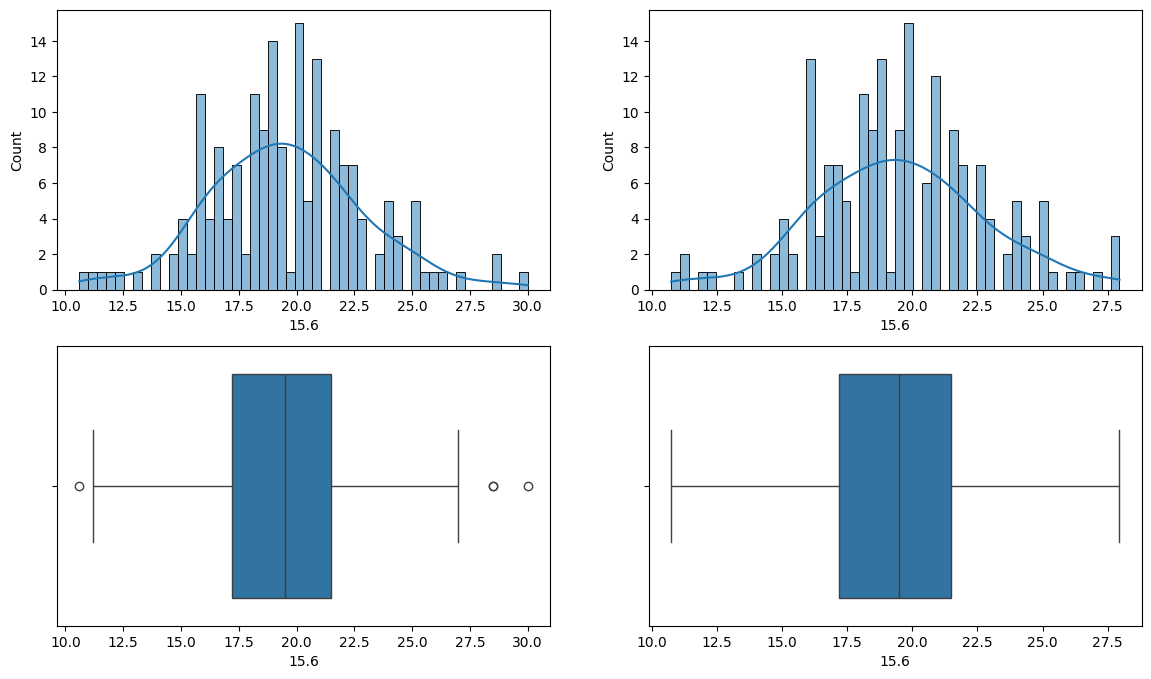

In [79]:
plt.figure(figsize=(14,8))
plt.subplot(221)
sns.histplot(df['15.6'],kde=True,bins=50)
plt.subplot(223)
sns.boxplot(x=df['15.6'])
plt.subplot(222)
sns.histplot(new_df_cap['15.6'],kde=True,bins=50)
plt.subplot(224)
sns.boxplot(x=new_df_cap['15.6'])
plt.show()